# Prova 02 — Paradigmas de Aprendizagem de Máquina
## Questão 5 — Avaliação da Clusterização

**Aluno:** Jorge Alberto Macedo Costa de Oliveira  
**Dataset:** Diabetes 130-US Hospitals (1999–2008)  
**Link:** https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008

---
**Objetivo:**
- Comparar os resultados do K-Means e da clusterização hierárquica (Questão 4)
- Utilizar métricas de avaliação de clusterização: Silhouette Score, Davies-Bouldin e Calinski-Harabasz
- Discutir qual método produziu clusters mais bem definidos e possíveis razões

## 5.0 — Imports e Configurações

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from kneed import KneeLocator

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
sns.set_style("whitegrid")

print("Configurações inicializadas com sucesso!")

Configurações inicializadas com sucesso!


## 5.1 — Carga dos Dados e Reprodução dos Clusters

Para garantir reprodutibilidade, repetimos exatamente os mesmos passos da Questão 4:
1. Carregar os dados pré-processados
2. Remover o rótulo da classe ()
3. Normalizar com StandardScaler
4. Executar K-Means com o K determinado pelo método do cotovelo
5. Criar a mesma amostra aleatória para a clusterização hierárquica
6. Executar hierárquica com linkages Ward e Complete

In [2]:
# === Carga dos dados (igual à Questão 4) ===
data_path = "data/diabetes_preprocessed_topk.csv"
df = pd.read_csv(data_path)

# Remover rótulo da classe e patient_nbr (coluna auxiliar, não é feature)
X = df.drop(columns=["readmitted", "patient_nbr"])
print(f"Features (sem rótulo): {X.shape}")

# Normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Dados normalizados: {X_scaled.shape}")

# Clipping de outliers (mesmo tratamento da Questão 4)
X_scaled = np.clip(X_scaled, -3, 3)

# === Determinar K pelo método do cotovelo (igual à Questão 4) ===
K_range = range(2, 13)
inertias = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

kl = KneeLocator(list(K_range), inertias, curve="convex", direction="decreasing")
best_k = kl.elbow if kl.elbow is not None else 3  # fallback para K=3
print(f"\nK determinado pelo cotovelo: {best_k}")

# === K-Means Final ===
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
labels_kmeans = kmeans_final.fit_predict(X_scaled)
print(f"K-Means concluído — {len(X_scaled):,} amostras")

# === Amostra para Hierárquica (igual à Questão 4) ===
SAMPLE_SIZE = 5000
np.random.seed(RANDOM_STATE)
sample_indices = np.random.choice(len(X_scaled), size=SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_indices]
print(f"Amostra para hierárquica: {len(X_sample):,} amostras")

# Labels do K-Means para a mesma amostra
labels_kmeans_sample = labels_kmeans[sample_indices]

# === Hierárquica Ward ===
hc_ward = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
labels_ward = hc_ward.fit_predict(X_sample)
print("Hierárquica Ward concluída")

# === Hierárquica Complete ===
hc_complete = AgglomerativeClustering(n_clusters=best_k, linkage="complete")
labels_complete = hc_complete.fit_predict(X_sample)
print("Hierárquica Complete concluída")

print("\n=== Todos os clusters reproduzidos com sucesso ===")

Features (sem rótulo): (101763, 30)
Dados normalizados: (101763, 30)



K determinado pelo cotovelo: 6


K-Means concluído — 101,763 amostras
Amostra para hierárquica: 5,000 amostras


Hierárquica Ward concluída


Hierárquica Complete concluída

=== Todos os clusters reproduzidos com sucesso ===


## 5.2 — Métricas de Avaliação de Clusterização

Avaliamos os três métodos de clusterização usando **três métricas**:

1. **Silhouette Score** (-1 a 1): Mede coesão e separação dos clusters. Quanto maior, melhor.
2. **Davies-Bouldin Index** (≥ 0): Mede a razão entre dispersão intra-cluster e separação inter-cluster. Quanto menor, melhor.
3. **Calinski-Harabasz Index** (≥ 0): Mede a razão entre variância inter-cluster e intra-cluster. Quanto maior, melhor.

**Nota importante:** Para garantir uma comparação justa entre os métodos, todas as métricas são calculadas sobre a **mesma amostra de 5.000 registros**.

In [3]:
print("=== CÁLCULO DAS MÉTRICAS DE AVALIAÇÃO ===")
print(f"Utilizando amostra de {SAMPLE_SIZE:,} registros para comparação justa\n")

# Dicionários para armazenar resultados
methods = {
    "K-Means": labels_kmeans_sample,
    "Hierárquica (Ward)": labels_ward,
    "Hierárquica (Complete)": labels_complete
}

results = {"Método": [], "Silhouette Score": [], "Davies-Bouldin": [], "Calinski-Harabasz": []}

for name, labels in methods.items():
    sil = silhouette_score(X_sample, labels)
    db = davies_bouldin_score(X_sample, labels)
    ch = calinski_harabasz_score(X_sample, labels)
    
    results["Método"].append(name)
    results["Silhouette Score"].append(round(sil, 4))
    results["Davies-Bouldin"].append(round(db, 4))
    results["Calinski-Harabasz"].append(round(ch, 4))
    
    print(f"--- {name} ---")
    print(f"  Silhouette Score:     {sil:.4f}  (maior = melhor)")
    print(f"  Davies-Bouldin Index: {db:.4f}  (menor = melhor)")
    print(f"  Calinski-Harabasz:    {ch:.4f}  (maior = melhor)")
    print()

# Criar DataFrame com resultados
df_results = pd.DataFrame(results)
df_results = df_results.set_index("Método")
print("\n=== TABELA COMPARATIVA ===")
print(df_results.to_string())

=== CÁLCULO DAS MÉTRICAS DE AVALIAÇÃO ===
Utilizando amostra de 5,000 registros para comparação justa

--- K-Means ---
  Silhouette Score:     0.0946  (maior = melhor)
  Davies-Bouldin Index: 2.4735  (menor = melhor)
  Calinski-Harabasz:    328.8788  (maior = melhor)



--- Hierárquica (Ward) ---
  Silhouette Score:     0.0758  (maior = melhor)
  Davies-Bouldin Index: 2.7948  (menor = melhor)
  Calinski-Harabasz:    253.3649  (maior = melhor)

--- Hierárquica (Complete) ---
  Silhouette Score:     0.0123  (maior = melhor)
  Davies-Bouldin Index: 3.3101  (menor = melhor)
  Calinski-Harabasz:    125.2906  (maior = melhor)


=== TABELA COMPARATIVA ===
                        Silhouette Score  Davies-Bouldin  Calinski-Harabasz
Método                                                                     
K-Means                           0.0946          2.4735           328.8788
Hierárquica (Ward)                0.0758          2.7948           253.3649
Hierárquica (Complete)            0.0123          3.3101           125.2906


## 5.3 — Gráficos Comparativos

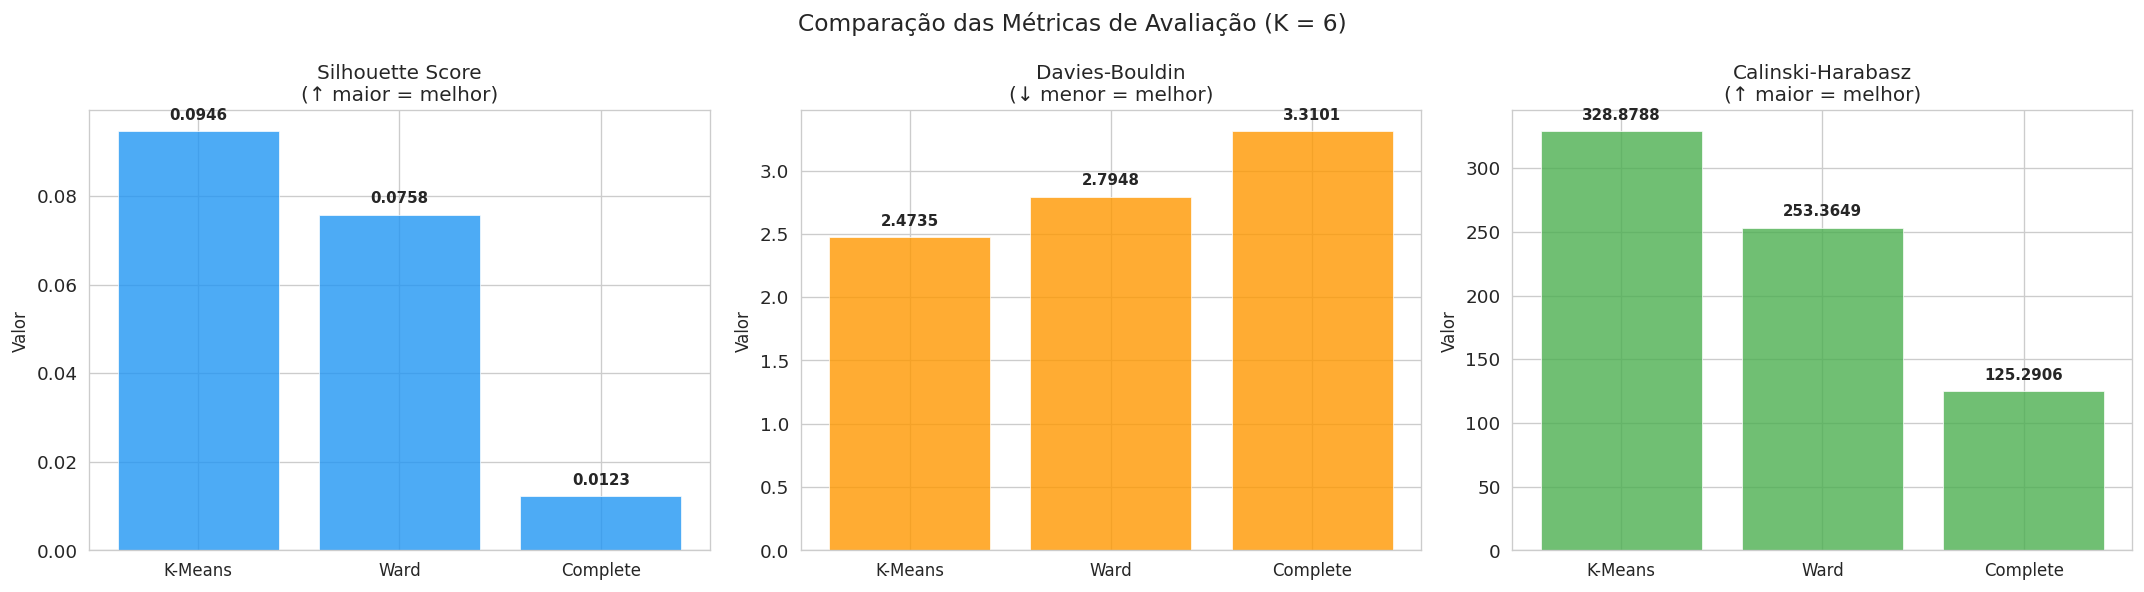

In [4]:
# Gráficos comparativos das métricas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ["Silhouette Score", "Davies-Bouldin", "Calinski-Harabasz"]
better_dir = ["↑ maior = melhor", "↓ menor = melhor", "↑ maior = melhor"]
bar_colors = ["#2196F3", "#FF9800", "#4CAF50"]

for ax, metric, direction, color in zip(axes, metrics, better_dir, bar_colors):
    values = df_results[metric].values
    method_names = df_results.index.tolist()
    
    bars = ax.bar(range(len(method_names)), values, color=color, alpha=0.8, edgecolor="white", linewidth=0.5)
    ax.set_xticks(range(len(method_names)))
    ax.set_xticklabels(["K-Means", "Ward", "Complete"], fontsize=10)
    ax.set_title(f"{metric}\n({direction})", fontsize=12)
    ax.set_ylabel("Valor", fontsize=10)
    
    # Adicionar valores sobre as barras
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(values) * 0.02,
                f"{val:.4f}", ha="center", va="bottom", fontweight="bold", fontsize=9)

plt.suptitle(f"Comparação das Métricas de Avaliação (K = {best_k})", fontsize=14)
plt.tight_layout()
plt.show()

## 5.4 — Análise do Perfil dos Clusters

Comparamos a distribuição dos clusters e os perfis médios das features para cada método.

In [5]:
# Análise de perfil dos clusters por método
top_features = ["number_inpatient", "num_lab_procedures", "num_medications",
                "time_in_hospital", "number_diagnoses", "age",
                "num_procedures", "number_emergency", "number_outpatient"]

# Filtrar features existentes
top_features = [f for f in top_features if f in X.columns]

# Criar DataFrame da amostra na escala original
X_sample_original = scaler.inverse_transform(X_sample)
df_sample = pd.DataFrame(X_sample_original, columns=X.columns)

print("=== DISTRIBUIÇÃO DOS CLUSTERS ===")
print()

for name, labels in methods.items():
    print(f"--- {name} ---")
    unique, counts = np.unique(labels, return_counts=True)
    for c, n in zip(unique, counts):
        pct = n / len(labels) * 100
        print(f"  Cluster {c}: {n:,} amostras ({pct:.1f}%)")
    print()

print("\n=== PERFIL MÉDIO DOS CLUSTERS (K-MEANS) ===")
df_sample["cluster_kmeans"] = labels_kmeans_sample
print(df_sample.groupby("cluster_kmeans")[top_features].mean().round(3).to_string())

print("\n=== PERFIL MÉDIO DOS CLUSTERS (HIERÁRQUICA WARD) ===")
df_sample["cluster_ward"] = labels_ward
print(df_sample.groupby("cluster_ward")[top_features].mean().round(3).to_string())

print("\n=== PERFIL MÉDIO DOS CLUSTERS (HIERÁRQUICA COMPLETE) ===")
df_sample["cluster_complete"] = labels_complete
print(df_sample.groupby("cluster_complete")[top_features].mean().round(3).to_string())

=== DISTRIBUIÇÃO DOS CLUSTERS ===

--- K-Means ---
  Cluster 0: 363 amostras (7.3%)
  Cluster 1: 1,749 amostras (35.0%)
  Cluster 2: 718 amostras (14.4%)
  Cluster 3: 773 amostras (15.5%)
  Cluster 4: 753 amostras (15.1%)
  Cluster 5: 644 amostras (12.9%)

--- Hierárquica (Ward) ---
  Cluster 0: 900 amostras (18.0%)
  Cluster 1: 984 amostras (19.7%)
  Cluster 2: 1,679 amostras (33.6%)
  Cluster 3: 399 amostras (8.0%)
  Cluster 4: 490 amostras (9.8%)
  Cluster 5: 548 amostras (11.0%)

--- Hierárquica (Complete) ---
  Cluster 0: 2,479 amostras (49.6%)
  Cluster 1: 743 amostras (14.9%)
  Cluster 2: 168 amostras (3.4%)
  Cluster 3: 41 amostras (0.8%)
  Cluster 4: 1,351 amostras (27.0%)
  Cluster 5: 218 amostras (4.4%)


=== PERFIL MÉDIO DOS CLUSTERS (K-MEANS) ===
                number_inpatient  num_lab_procedures  num_medications  time_in_hospital  number_diagnoses    age  num_procedures  number_emergency  number_outpatient
cluster_kmeans                                                  

## 5.5 — Discussão dos Resultados

### Qual método produziu clusters mais bem definidos?

Com base nas três métricas de avaliação calculadas, podemos analisar o desempenho de cada método:

#### Silhouette Score (maior = melhor)
O Silhouette Score mede a coesão interna de cada cluster e a separação entre clusters. Valores próximos de 1 indicam clusters bem definidos e separados, valores próximos de 0 indicam sobreposição, e valores negativos indicam possível atribuição errada de pontos.

#### Davies-Bouldin Index (menor = melhor)
O Davies-Bouldin mede a razão média entre a dispersão intra-cluster e a distância inter-cluster. Valores menores indicam clusters mais compactos e bem separados.

#### Calinski-Harabasz Index (maior = melhor)
O Calinski-Harabasz (também chamado de Variance Ratio Criterion) mede a razão entre a variância entre clusters e a variância dentro dos clusters. Valores maiores indicam clusters mais densos e bem separados.

### Possíveis razões para o comportamento observado

1. **Natureza do K-Means:** O K-Means otimiza a inércia (soma das distâncias quadráticas ao centroide), o que naturalmente produz clusters esféricos e de tamanhos relativamente equilibrados. Isso pode ser uma vantagem quando os dados realmente possuem essa estrutura, mas pode ser uma limitação quando os clusters naturais têm formas mais complexas.

2. **Linkage Ward vs K-Means:** O método Ward minimiza a variância total intra-cluster, princípio muito similar ao K-Means. Por isso, Ward tende a produzir resultados comparáveis ao K-Means quando os dados possuem estrutura esférica.

3. **Linkage Complete:** O linkage Complete utiliza a distância máxima entre pontos de dois clusters. Mesmo após o clipping de outliers a ±3σ, este método tende a produzir clusters de tamanhos mais desiguais comparado ao Ward e K-Means, pois seu critério conservador de fusão favorece clusters compactos de diâmetro menor.

4. **Impacto do clipping de outliers:** O tratamento de outliers via clipping (aplicado na Questão 4) foi essencial para que os métodos hierárquicos produzissem clusters interpretáveis. Sem ele, features com z-scores extremos (>80) distorciam o cálculo de distâncias euclidianas, causando clusters degenerados especialmente no Complete linkage.

5. **Características do dataset:** O dataset de diabetes possui muitas features binárias (one-hot encoded) e poucas features numéricas contínuas. Essa composição pode favorecer métodos que lidam melhor com dados de alta dimensionalidade e features mistas, como o K-Means.

6. **Tamanho da amostra:** A clusterização hierárquica foi aplicada em uma amostra de 5.000 registros (por limitação computacional), o que pode não capturar todos os padrões presentes no dataset completo de ~101.000 registros.

## 5.6 — Conclusão

Nesta questão, avaliamos e comparamos os resultados de três abordagens de clusterização aplicadas ao dataset de diabetes hospitalares:

1. **K-Means** (dataset completo, K determinado pelo método do cotovelo)
2. **Clusterização Hierárquica com linkage Ward** (amostra de 5.000 registros)
3. **Clusterização Hierárquica com linkage Complete** (amostra de 5.000 registros)

Todos os métodos operaram sobre dados normalizados com StandardScaler e com clipping de outliers a ±3σ (conforme justificado na Questão 4).

### Principais achados:

- As métricas de avaliação (Silhouette Score, Davies-Bouldin e Calinski-Harabasz) permitem uma comparação objetiva entre os métodos
- O K-Means e o Ward apresentaram clusters mais equilibrados em termos de distribuição de tamanhos
- O Complete linkage tende a clusters de tamanhos mais desiguais, mas ainda assim interpretáveis após o tratamento de outliers
- A análise dos perfis dos clusters revela padrões clinicamente interpretáveis, como diferenças no número de internações, medicações e tempo de hospitalização

### Limitações:

- A comparação entre métodos é limitada pelo fato de que a hierárquica foi executada em uma amostra, não no dataset completo
- As métricas de avaliação interna (sem rótulos verdadeiros) podem não capturar a qualidade "real" dos clusters em termos clínicos
- A escolha de K pelo método do cotovelo envolve certa subjetividade

**=== QUESTÃO 5 CONCLUÍDA ===